# Normalization module
The normalization module of the SUIT toolbox calculates a deformation field that maps the cerebellum of an individual subject to the SUIT template, using the mask generated by the isolation module. The Python-version uses the ANTSPy package to perform the normalization and will be released with version 2.1. The deformation field can then be used to reslice functional and anatomical data into SUIT space.

This notebook shows more detailed usage and options for the normalization module. We assume you have produced an isolation mask (``<basename>_cerebellum_desg.nii.gz``) as described in the last step. 

In [1]:
# Import necessary packages
from nilearn import plotting as npl
import SUITPy as suit
import nibabel as nib
import matplotlib.pyplot as plt

## Basic usage 
In the simplest case, `normalize` function takes the T1-weight image and isolation mask (``<basename>_cerebellum_desg.nii.gz`` from `isolation` function) as two parameters: 


In [2]:
# This function normalizes a source image to the SUIT cerebellar template using a provided cerebellum mask.
results = suit.normalize(source_file = 'sub-ex_T1w.nii.gz',
                 mask_file = 'sub-ex_T1w_cerebellum_dseg.nii.gz',
                 verbose = 1)

Normalizing sub-ex_T1w to tpl-SUIT_T1w.nii.gz
Saving the normalized image into sub-ex_T1w_space-SUIT.nii.gz
Saving deformation field into sub-ex_T1w_to-SUIT_mode-image_xfm.nii.gz


Results is a dictionary that contains the filenames of the saved files. 

By default, ``normalize`` saves two files: 

* The deformation field required to reslice images into SUIT space: ``<Basename>_to-SUIT_mode-image_xfm.nii.gz``
* The resliced and masked anatomical in SUIT space: ``<Basename>_space-SUIT.nii.gz``

## Checking the normalization
Even though normalization usually works well, it is useful to check the alignment: 

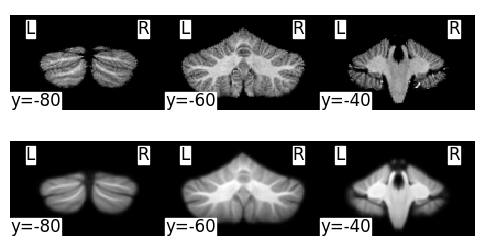

In [6]:
w_anat_img = nib.load(results['normalized_image'])
template_img = nib.load('../../../SUITPy/templates/tpl-SUIT_T1w.nii.gz')
plt.figure(figsize=(6,3))
ax=plt.subplot(2,1,1)
npl.plot_img(w_anat_img,display_mode='y',cut_coords=[-80.0,-60.0,-40.0] , colorbar=False,axes=ax)
ax=plt.subplot(2,1,2)
npl.plot_img(template_img,display_mode='y',cut_coords=[-80.0,-60.0,-40.0] ,colorbar=False,axes=ax)

## Saving the Jacobian determinant
Set `write_jacobian_determinant=True` to save Jacobian determinant maps.
The default output is the log-transformed geometric Jacobian determinant.

This file is useful for volumetric or VBM analyses

In [5]:
# Saving the Jacobian determinant maps.
results = suit.normalize(source_file = 'sub-ex_T1w.nii.gz',
                 mask_file = 'sub-ex_T1w_cerebellum_dseg.nii.gz',
                 space = 'MNISym',
                 write_jacobian_determinant=True,
                 verbose = 0)

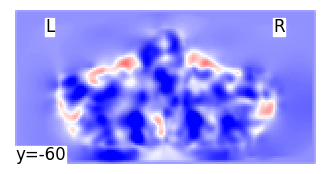

In [12]:
# Plot the log-jacobian. 
log_jac = nib.load(results['jacobian_determinant'])
plt.figure(figsize=(4,2))
npl.plot_img(log_jac,display_mode='y',cut_coords=[-60.0] , colorbar=False, vmin=-1,vmax=1,cmap='bwr',axes=plt.gca())


## Saving the ants transform files
If you are familiar with ANTS and would like to work with the transformation files save in any format, you can use: 



In [ ]:
# Set write_ants_transform=True to save the ants transformation files.
results = suit.normalize(source_file = 'sub-ex_T1w.nii.gz',
                 mask_file = 'sub-ex_T1w_cerebellum_dseg.nii.gz',
                 space = 'MNISym',
                 write_ants_transform=True,
                 verbose = 0)

## Using inverse deformations 
If you want to bring a group template of atlas into the space of an individual, you need the inverse deformation file. 
To save that inverse deformation set `write_inv_deformation` to `True`. 

In [2]:
# Set write_ants_transform=True to save the ants transformation files.
results = suit.normalize(source_file = 'sub-ex_T1w.nii.gz',
                 mask_file = 'sub-ex_T1w_cerebellum_dseg.nii.gz',
                 write_inv_deformation=True,
                 verbose = 0)

The inverse deformation is saved as `sub-ex_T1w_from-SUIT_mode-image_xfm.nii.gz`. 

We then can reslice the the atlas for the Buckner networks from SUIT into the individual space. 

*Note: because the atlas is a label file, we need to use nearest-neighbour interpolation here*

In [4]:
# Set write_ants_transform=True to save the ants transformation files.
buckner_img = suit.reslice_image('Buckner_17Networks.nii',
                   deformation = results['inv_deformation'],
                   interp=0)

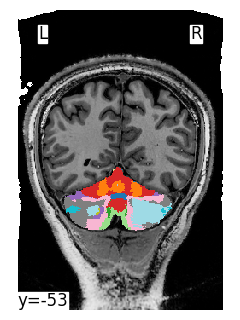

In [10]:
npl.plot_img(buckner_img,display_mode='y',threshold=0.1, cut_coords=[-53.0], bg_img='sub-ex_T1w.nii.gz',colorbar=False,cmap='tab20')


## Other  Template space
By default, the image is normalized to the SUIT cerebellar template. For compatibility the toolbox support three different cerebellar-only templates

* `SUIT`: The original SUIT template from Diedrichsen (2005). 
* `MNI`:  A cerebellar-only version of the `MNI152NLin6Asym` template used for example in FSL. 
* `MNISym`: A cerebellar-only version if the `MNI152NLin2009cSymC` template for symmetric analyses 



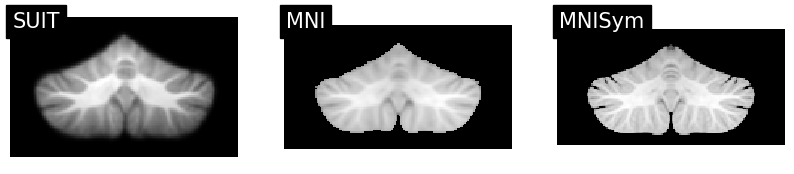

In [9]:
SUIT_template_img = nib.load('../../../SUITPy/templates/tpl-SUIT_T1w.nii.gz')
MNI_template_img = nib.load('../../../SUITPy/templates/tpl-MNI152NLin6AsymC_T1w.nii.gz')
MNISym_template_img = nib.load('../../../SUITPy/templates/tpl-MNI152NLin2009cSymC_T1w.nii.gz')

plt.figure(figsize=(10,2))
ax=plt.subplot(1,3,1)
npl.plot_img(SUIT_template_img,display_mode='y',cut_coords=[-60.0],title='SUIT',colorbar=False,axes=ax,annotate=False)
ax=plt.subplot(1,3,2)
npl.plot_img(MNI_template_img,display_mode='y',cut_coords=[-60.0],title='MNI',colorbar=False,axes=ax,annotate=False)
ax=plt.subplot(1,3,3)
npl.plot_img(MNISym_template_img,display_mode='y',cut_coords=[-60.0],title='MNISym',colorbar=False,axes=ax,annotate=False)


If you want to use a different target space, simply specify the ``space`` parameter: `SUIT`, `MNI152NLin6AsymC` / 'MNI', `MNI152NLin2009cSymC` / 'MNISym'.

If you wish to use a custom cerebellum-only template that is not included in these options, you can provide a file directly using the ``template_file`` parameter: Optional path to a custom template file

In [ ]:
# This function normalizes a source image to the MNI152NLin2009cSymC space using a provided cerebellum mask.
results = suit.normalize(source_file = 'sub-ex_T1w.nii.gz',
                 mask_file = 'sub-ex_T1w_cerebellum_dseg.nii.gz',
                 space = 'MNISym',
                 verbose = 0)

## Transforms between different template spaces 
Even though the atlas templates are very close to each other, the normalization will differ ever so slightly. 

If you have data in one cerebellar space, and you would like to transform it to another, the [Cerebellar Atlas](https://github.com/diedrichsenlab/cerebellar_atlases) repository contains the deformation files between different atlas spaces. 

For example if you have data in SUIT space, and want to transform it to MNISym space:  

In [18]:
# If you have not downloaded it yet, you need to fetch the xfm files from SUIT to MNISym space from cerebellar atlas repository first
import urllib.request
import os
url = ("https://raw.githubusercontent.com/DiedrichsenLab/cerebellar_atlases/master/tpl-MNI152NLin2009cSymC/tpl-MNI152NLin2009cSymC_from-SUIT_mode-image_xfm.nii")
xfm_file = "tpl-MNI152NLin2009cSymC_from-SUIT_mode-image_xfm.nii"
urllib.request.urlretrieve(url, xfm_file)

('tpl-MNI152NLin2009cSymC_from-SUIT_mode-image_xfm.nii',
 <http.client.HTTPMessage at 0x38ff22210>)

In [ ]:
# then reslice the SUIT-space image to MNISym space
xfm_file = "cerebellar_atlases/tpl-MNI152NLin2009cSymC/tpl-MNI152NLin2009cSymC_from-SUIT_mode-image_xfm.nii"
output_img = suit.reslice_image(source_image = 'sub-ex_T1w_space-SUIT.nii.gz',
        deformation = xfm_file)